# Disciplina de Processamento Digital de Imagens
Departamento de Computação
São Carlos, SP - Brasil

Detecção de fumaça e fogo em ambientes florestais

Grupo 7:
- Caio Ueda        802215
- Gabriel Spolon   811649


Este projeto tem como objetivo desenvolver uma abordagem para detecção de fogo e fumaça em imagens estáticas de ambientes florestais, combinando técnicas tradicionais de processamento digital de imagens com métodos de aprendizado de máquina. A identificação automática desses elementos é uma ferramenta essencial em sistemas de monitoramento ambiental e no combate a incêndios florestais, permitindo respostas mais rápidas e eficazes.
Serão exploradas técnicas clássicas como análise de cor, textura e detecção de bordas para extração de características relevantes das imagens. Com base nesses atributos, diferentes modelos de aprendizado de máquina serão treinados e avaliados para classificar as imagens quanto à presença de fogo e/ou fumaça.


## Banco de dados

O nome do dataset selecionado é _Forest Fire Smoke and Non-Fire Image Dataset_, disponível publicamente na plataforma Kaggle (https://www.kaggle.com/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset). Esse conjunto é composto por mais de 42 mil imagens distribuídas em três categorias principais: fogo, fumaça e sem fogo.

As imagens foram capturadas em ambientes naturais diversos, como florestas e áreas abertas, contemplando diferentes condições visuais. Essa variabilidade é um fator relevante, pois contribui para a generalização e robustez dos modelos de aprendizado de máquina treinados com esses dados. Além disso, o volume expressivo do dataset torna-o adequado para a aplicação de técnicas supervisionadas de classificação de imagens.

link de acesso: [Forest_Fire_Smoke_and_Non_Fire_Image_Dataset](https://www.kaggle.com/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset):https://www.kaggle.com/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset

### Importando Data Set

In [58]:
import os
import kagglehub

# Nome esperado da pasta local
nome_pasta_local = "FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET"
caminho_local = os.path.join(os.getcwd(), nome_pasta_local)

# Verifica se a pasta já existe no diretório atual
if os.path.exists(caminho_local):
    print("Dataset encontrado localmente.")
    path_dataset = os.getcwd()
else:
    print("Dataset não encontrado localmente. Baixando do Kaggle...")
    path_dataset = kagglehub.dataset_download("amerzishminha/forest-fire-smoke-and-non-fire-image-dataset")

print("\nPath até o dataset:", path_dataset)
print("Pasta contendo o dataset:")
!ls {(path_dataset)}


Dataset encontrado localmente.

Path até o dataset: c:\Users\arcoc\github\TRABALHO
Pasta contendo o dataset:
FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET
PDI_Projeto.ipynb
README.md
dataset_preprocessed
img
requirements.txt
venv


## Pré Processamento

### Redimensionando e Normalizando Imagens

In [59]:
import os
from PIL import Image
import numpy as np

nome_pasta_original = "FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET"
caminho_completo_dataset = os.path.join(path_dataset, nome_pasta_original)
caminho_preprocessado = os.path.join(os.getcwd(), "dataset_preprocessed")

subpastas = ['fire', 'non fire', 'Smoke']
nomes_rotulos = {'fire': 0, 'non fire': 1, 'Smoke': 2}
tamanho_padrao = (224, 224)

def processar_e_salvar_imagens(origem, destino):
    os.makedirs(destino, exist_ok=True)
    for subpasta in subpastas:
        caminho_subpasta_origem = os.path.join(origem, subpasta)
        caminho_subpasta_destino = os.path.join(destino, subpasta)
        os.makedirs(caminho_subpasta_destino, exist_ok=True)

        for nome_arquivo in os.listdir(caminho_subpasta_origem):
            if nome_arquivo.endswith(('.jpg', '.jpeg', '.png')):
                caminho_imagem_origem = os.path.join(caminho_subpasta_origem, nome_arquivo)
                caminho_imagem_destino = os.path.join(caminho_subpasta_destino, nome_arquivo)
                try:
                    imagem = Image.open(caminho_imagem_origem).convert('RGB')
                    imagem_redimensionada = imagem.resize(tamanho_padrao)
                    imagem_redimensionada.save(caminho_imagem_destino)
                except Exception as e:
                    print(f"Erro ao processar {caminho_imagem_origem}: {e}")

def carregar_dataset(diretorio_principal):
    imagens = []
    rotulos = []

    for subpasta in subpastas:
        caminho_subpasta = os.path.join(diretorio_principal, subpasta)
        for nome_arquivo in os.listdir(caminho_subpasta):
            if nome_arquivo.endswith(('.jpg', '.jpeg', '.png')):
                caminho_imagem = os.path.join(caminho_subpasta, nome_arquivo)
                try:
                    imagem = Image.open(caminho_imagem).convert('RGB')
                    array_img = np.array(imagem).astype('float32') / 255.0  # Normalizado aqui
                    imagens.append(array_img)
                    rotulos.append(nomes_rotulos[subpasta])
                except Exception as e:
                    print(f"Erro ao carregar a imagem: {caminho_imagem} - {e}")
    return np.array(imagens), np.array(rotulos)

# Verificação e processamento
if not os.path.exists(caminho_preprocessado):
    print("Pasta de imagens pré-processadas não encontrada. Processando e salvando no disco...")
    for conjunto in ['train', 'test']:
        origem = os.path.join(caminho_completo_dataset, conjunto)
        destino = os.path.join(caminho_preprocessado, conjunto)
        processar_e_salvar_imagens(origem, destino)
else:
    print("Imagens pré-processadas já existem. Carregando diretamente...")

# Carregamento das imagens
caminho_dataset_train = os.path.join(caminho_preprocessado, 'train')
caminho_dataset_test = os.path.join(caminho_preprocessado, 'test')

imagens_treino, rotulos_treino = carregar_dataset(caminho_dataset_train)
imagens_teste, rotulos_teste = carregar_dataset(caminho_dataset_test)

print("Shape do array de imagens de treino:", imagens_treino.shape)
print("Shape do array de rótulos de treino:", rotulos_treino.shape)
print("Shape do array de imagens de teste:", imagens_teste.shape)
print("Shape do array de rótulos de teste:", rotulos_teste.shape)


Imagens pré-processadas já existem. Carregando diretamente...
Shape do array de imagens de treino: (31698, 224, 224, 3)
Shape do array de rótulos de treino: (31698,)
Shape do array de imagens de teste: (9443, 224, 224, 3)
Shape do array de rótulos de teste: (9443,)


### Identificando possíveis ruídos

A partir de uma amostra de imagens, serão realizadas inspeções visuais e análises estatísticas para identificar possíveis ruídos presentes.

As etapas são:
1. Inspeção Visual: etapa em que apenas o olho humano é usado para analisar a imagem e verificar se há algum padrão de ruído.
2. Análise Estatística: etapa em que medidas estatísticas são calculadas para avaliar a distribuição dos valores de intensidade dos pixels.
    - **Histograma**: histograma da imagem é calculado e analisado para verificar se há uma distribuição normal ou se há uma concentração de valores de intensidade em um intervalo específico.
    - **Variância Local**: a variância local da imagem é calculada e analisada para identificar regiões com alta variação de intensidade.
    - **Histograma de Textura (LBP)**: o LBP (Local Binary Pattern) é um descritor de textura que compara cada pixel com seus vizinhos e codifica os padrões locais em números inteiros. O histograma desses padrões reflete a complexidade e repetição da textura da imagem. Texturas finas e homogêneas tendem a gerar histogramas concentrados, enquanto texturas mais complexas produzem distribuições mais dispersas.

Das imagens de treino, selecionaremos 3 amostras pertencentes a cada um dos rótulos, fogo, sem fogo e fumaça.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0401408369251032e-25..1.0000000000000002].


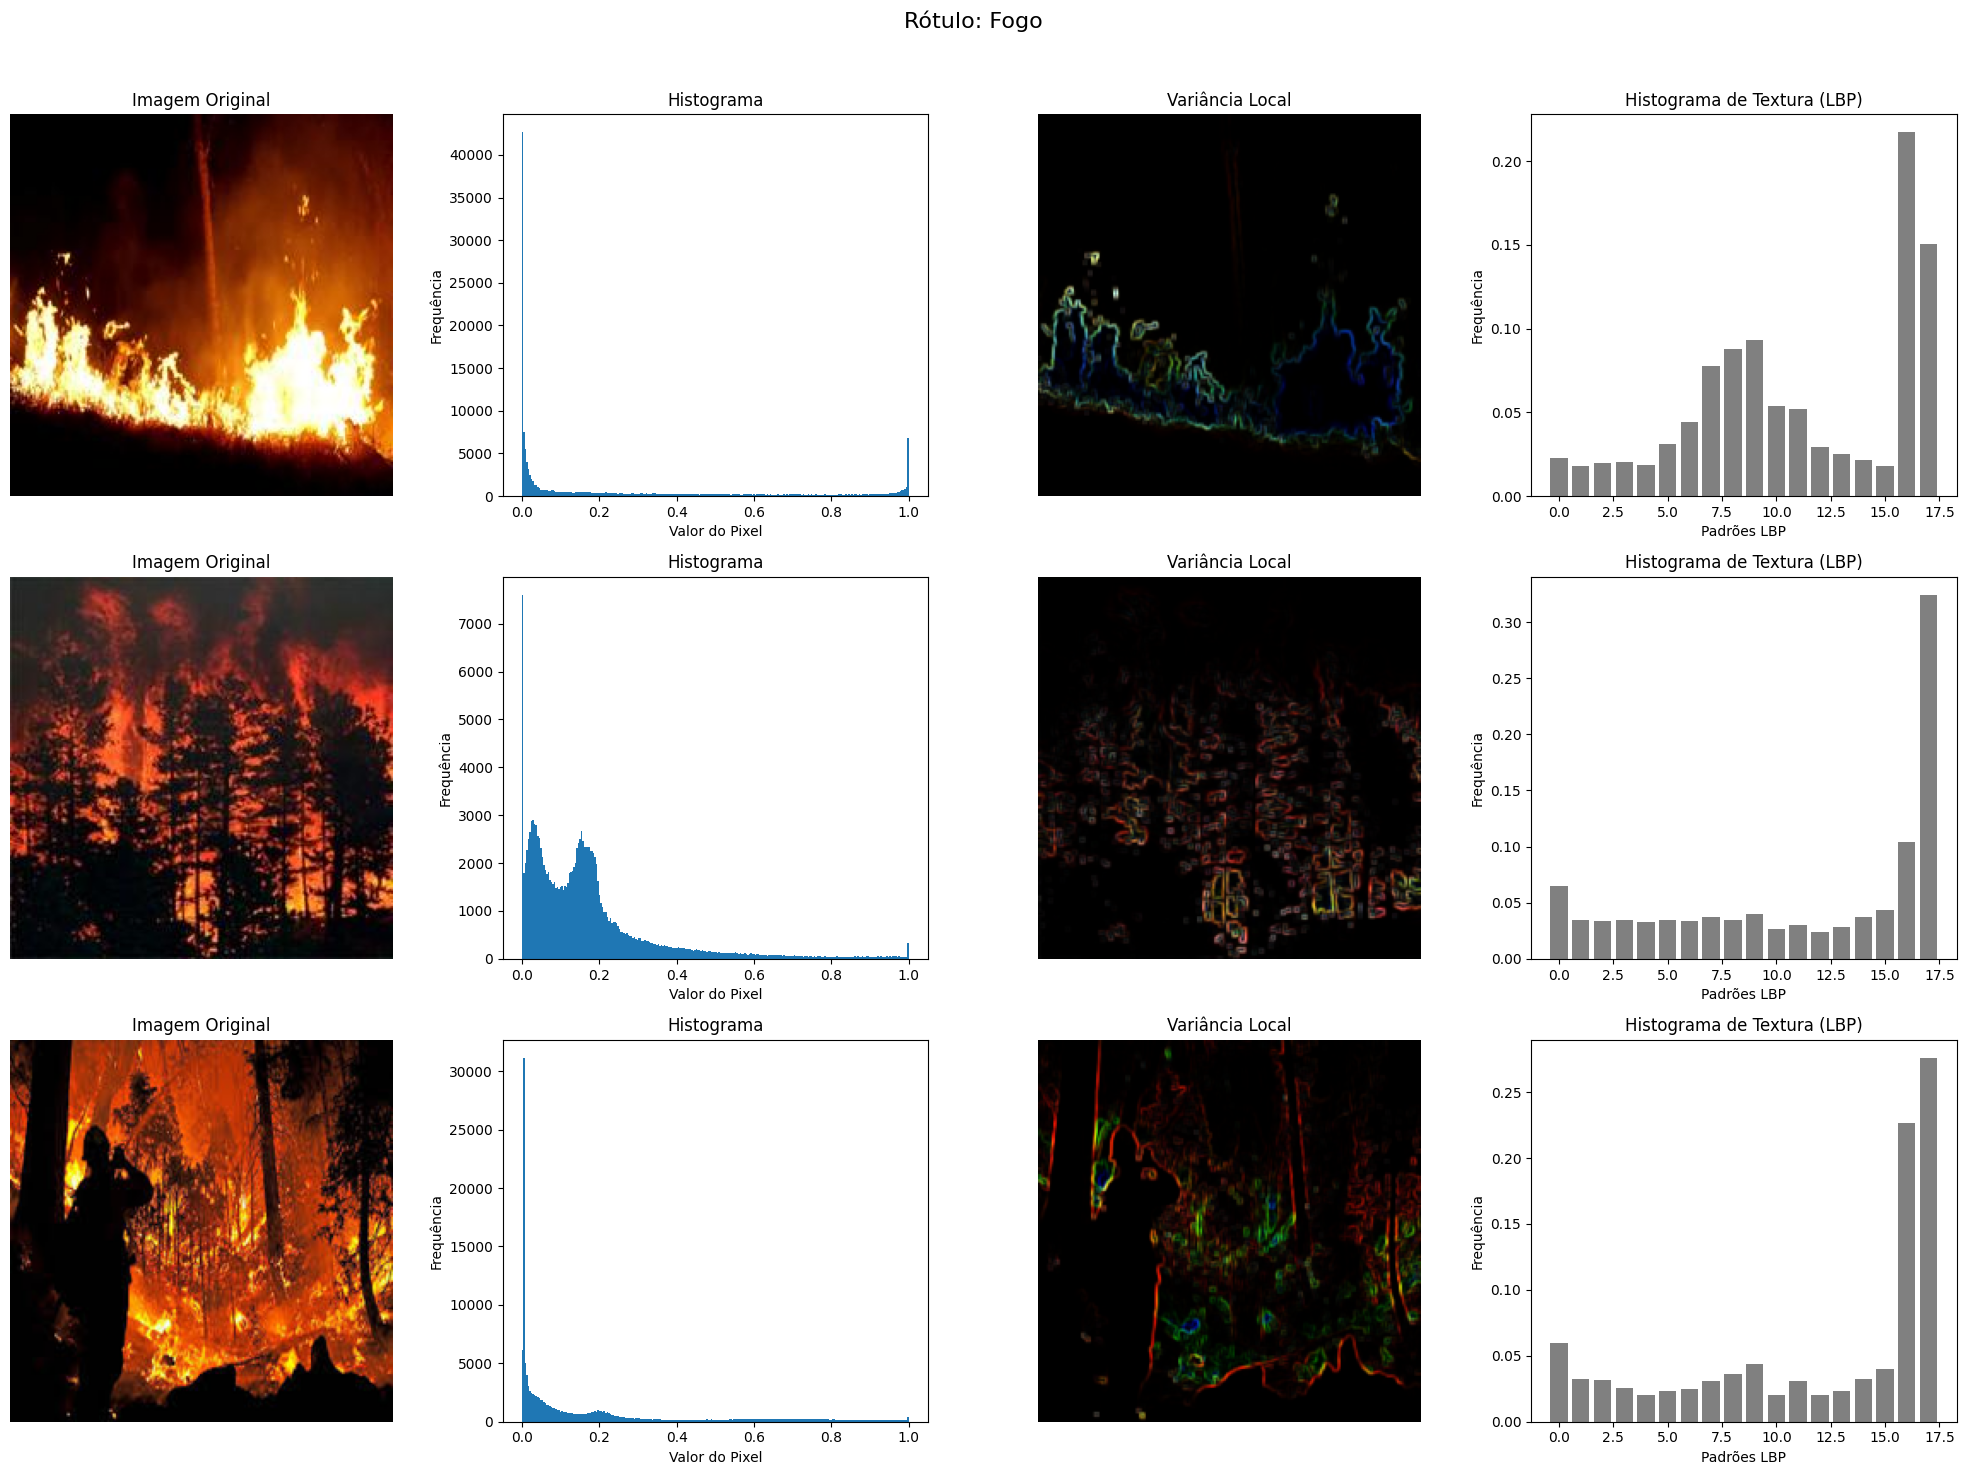

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.775522136203992e-22..1.0].


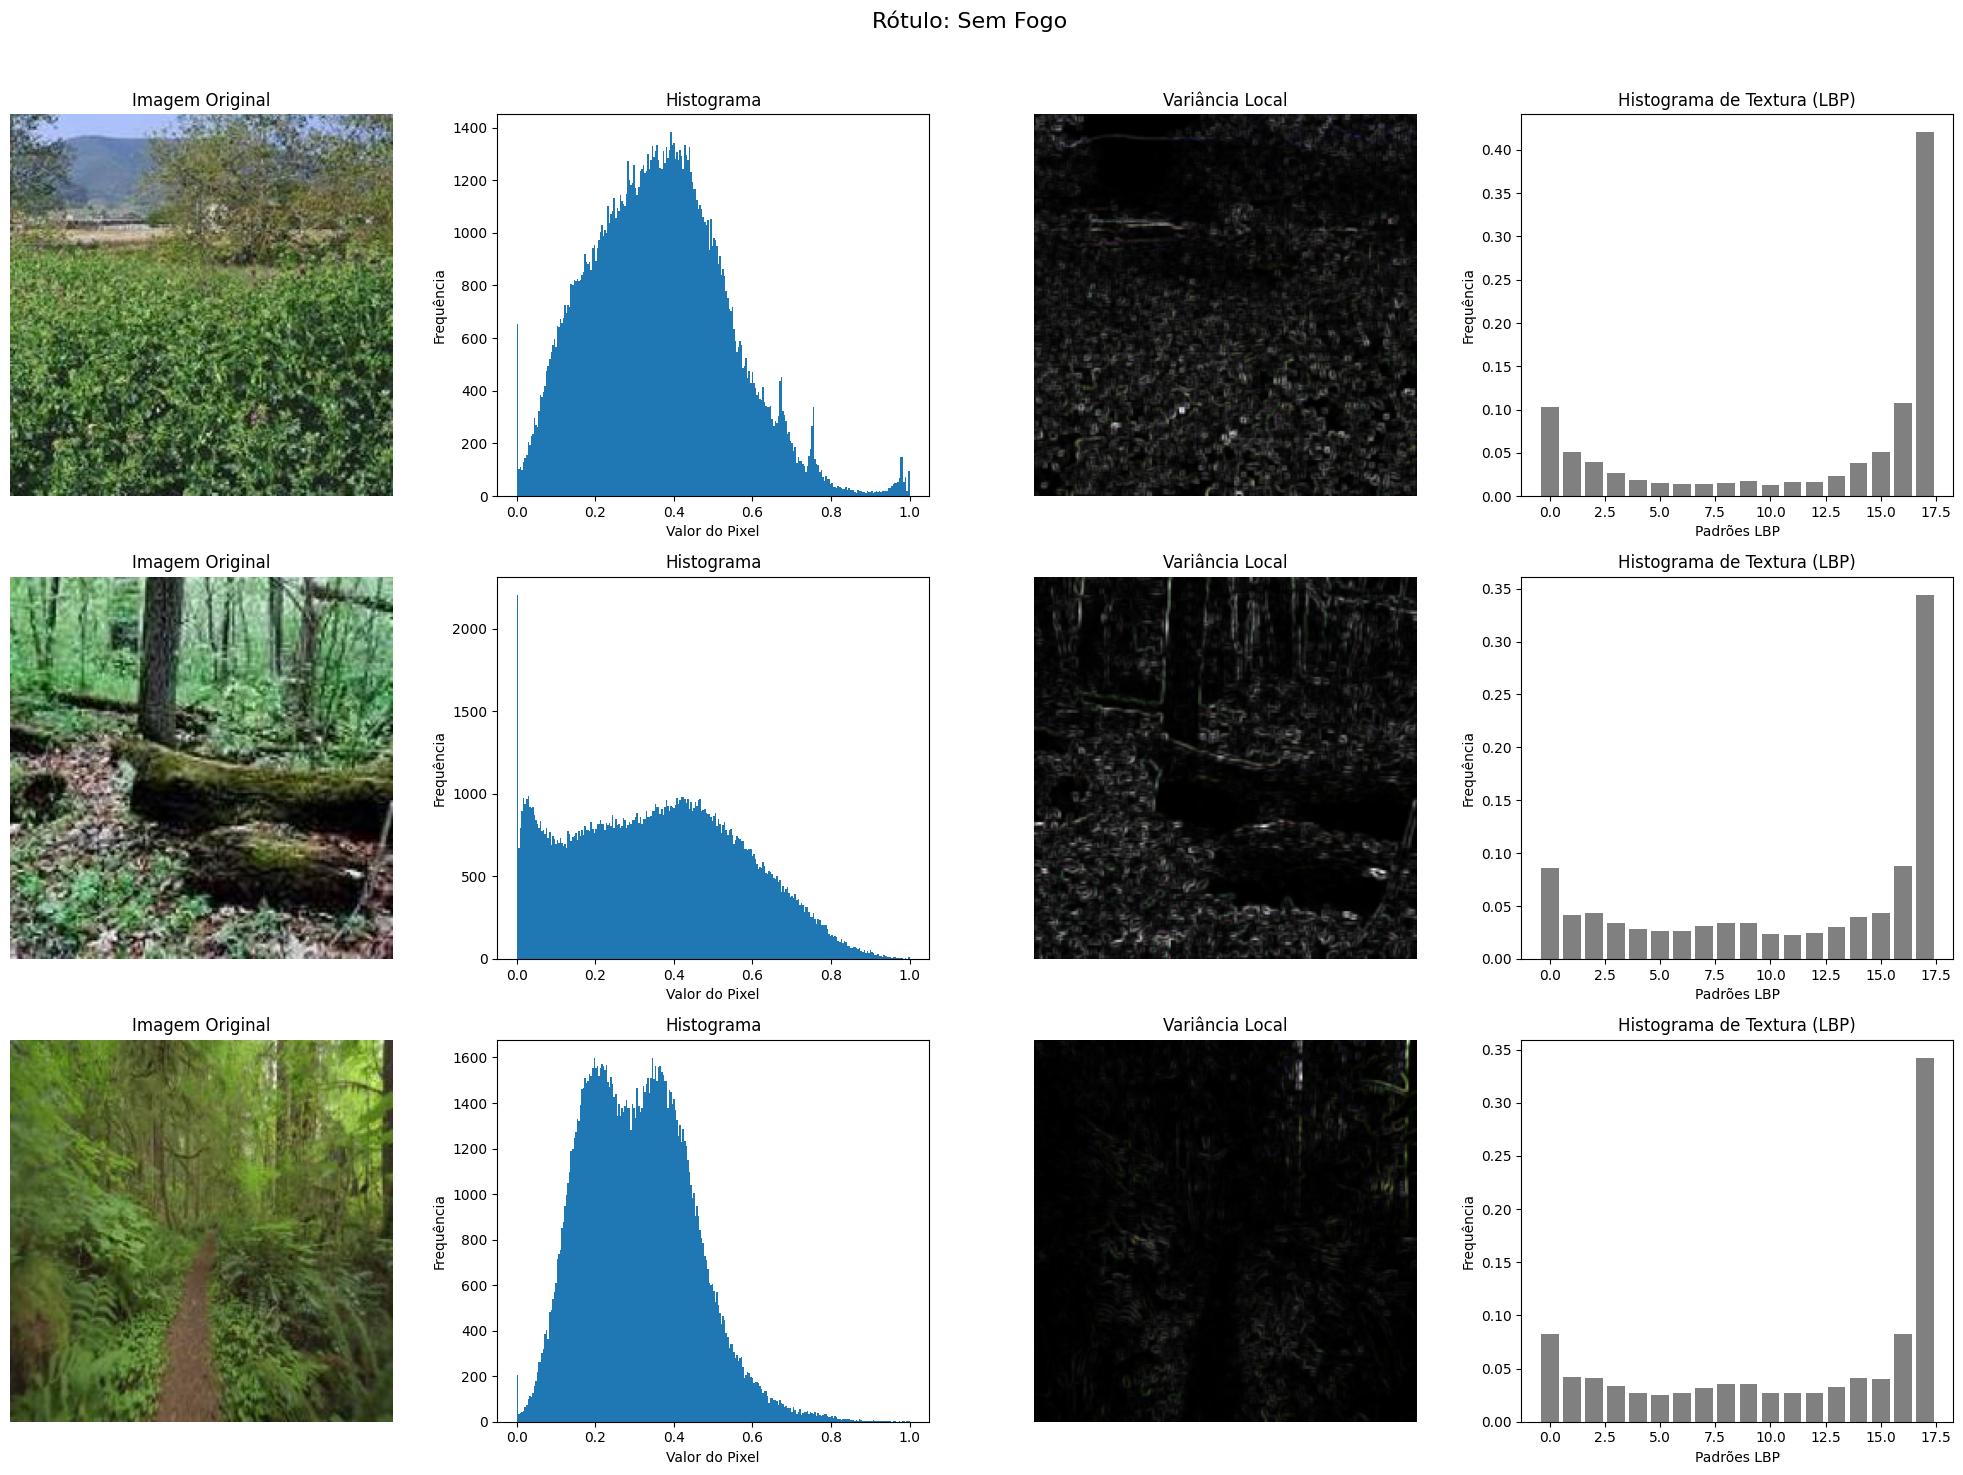

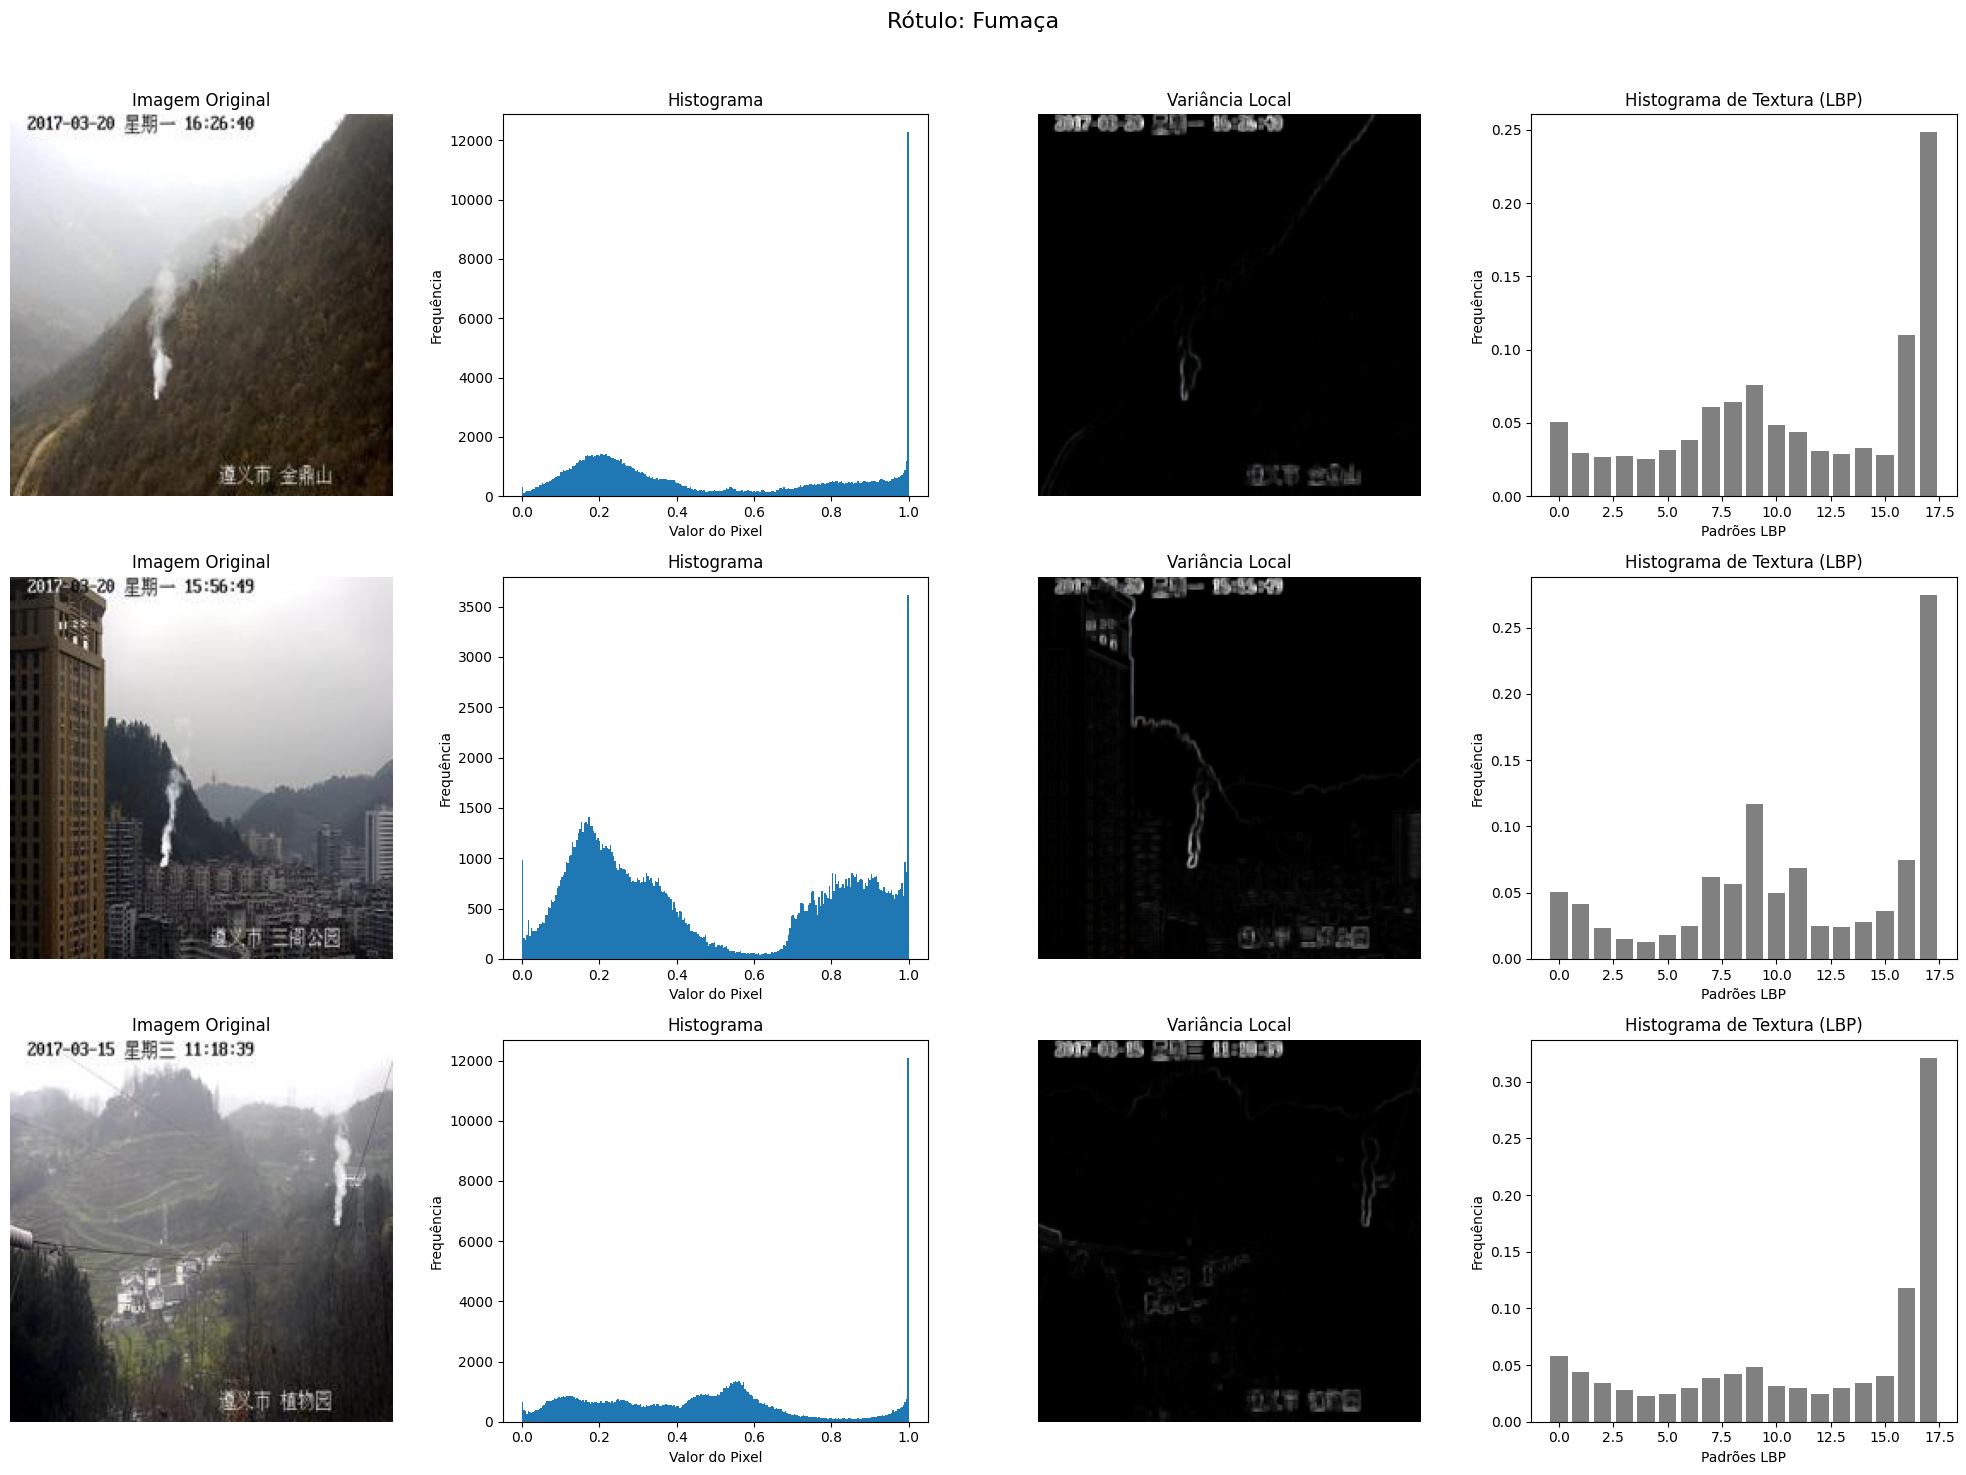

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

# Parâmetros do LBP
radius = 2  # raio da vizinhança
n_points = 8 * radius  # número de vizinhos

num_amostras_por_rotulo = 3
rotulos_significado = {0: 'Fogo', 1: 'Sem Fogo', 2: 'Fumaça'}

np.random.seed(33)
for rotulo in np.unique(rotulos_treino):
    indices_rotulo = np.where(rotulos_treino == rotulo)[0]
    indices_amostra = np.random.choice(indices_rotulo, num_amostras_por_rotulo, replace=False)

    plt.figure(figsize=(20, 5 * num_amostras_por_rotulo))
    plt.suptitle(f'Rótulo: {rotulos_significado[rotulo]}', fontsize=16)

    for i, indice_imagem in enumerate(indices_amostra):
        imagem = imagens_treino[indice_imagem]

        # Imagem original
        plt.subplot(num_amostras_por_rotulo, 4, 4 * i + 1)
        plt.imshow(imagem)
        plt.title('Imagem Original')
        plt.axis('off')

        # Histograma de intensidade
        plt.subplot(num_amostras_por_rotulo, 4, 4 * i + 2)
        plt.hist(imagem.ravel(), bins=256, range=(0, 1))
        plt.title('Histograma')
        plt.xlabel('Valor do Pixel')
        plt.ylabel('Frequência')

        # Variância Local
        imagem_float64 = imagem.astype(np.float64)
        kernel = np.ones((3, 3), np.float32) / 9
        imagem_quadrado = np.square(imagem_float64)
        media_local = cv2.filter2D(imagem_float64, -1, kernel)
        media_quadrado_local = cv2.filter2D(imagem_quadrado, -1, kernel)
        variancia_local = media_quadrado_local - np.square(media_local)
        variancia_vis = cv2.normalize(variancia_local, None, 0, 1, cv2.NORM_MINMAX)

        plt.subplot(num_amostras_por_rotulo, 4, 4 * i + 3)
        plt.imshow(variancia_vis, cmap='gray')
        plt.title('Variância Local')
        plt.axis('off')

        # Análise de Textura com LBP
        img_gray = cv2.cvtColor((imagem * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')
        (hist_lbp, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
        hist_lbp = hist_lbp.astype("float")
        hist_lbp /= (hist_lbp.sum() + 1e-6)

        plt.subplot(num_amostras_por_rotulo, 4, 4 * i + 4)
        plt.bar(range(len(hist_lbp)), hist_lbp, width=0.8, color='gray')
        plt.title('Histograma de Textura (LBP)')
        plt.xlabel('Padrões LBP')
        plt.ylabel('Frequência')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Análise das Imagens da Classe **Fogo**

### Análise Visual
As imagens apresentam cenas de incêndio com chamas laranjas/amarelas intensas. Não é possível identificar a presença de algum ruído específico.

### Histograma  
Histogramas fortemente concentrados em valores baixos, com quedas abruptas.
Picos secundários pequenos em valores mais altos, próximos a 1 na primeira imagem, possivelmente indicando a parte mais clara das chamas.
As imagens analisadas contêm muitos pontos escuros na imagem, o que leva a uma concentração em valores baixos com transições abruptas, o que pode mascarar ruídos de baixa intensidade.

### Variância Local  
Variância local com padrões coloridos intensos nas bordas das chamas.
Alta variância nas regiões de transição entre chamas e fundo.
Padrões mais complexos e coloridos indicam mudanças abruptas de intensidade características do fogo, não necessariamente ruído.

### Espectro de Fourier 
Espectros com padrão central brilhante e dispersão mais uniforme.
Presença moderada de componentes de alta frequência.
A combinação de componentes de baixa e alta frequência reflete a natureza complexa das chamas, com transições abruptas que podem ser confundidas com ruído.

### Histogramas de Textura (LBP)
Picos pronunciados em padrões específicos (4 e 8-9).
Distribuição mais polarizada entre certos padrões.
A concentração em padrões específicos indica características texturais do fogo, não necessariamente ruído.

---

## Análise das Imagens da Classe **Sem Fogo**

### Análise Visual
As imagens apresentam cenas de vegetação verde, florestas e campos. Não é possível identificar a presença de algum ruído específico.

### Histograma  
Histogramas mais amplos e com distribuição mais equilibrada.
Presença de pequenos picos irregulares, especialmente na terceira imagem (dois picos distintos), cuja distribuição sugere variabilidade natural, mas não necessariamente ruído.

### Variância Local  
Variância local com mais pontos brilhantes distribuídos nas áreas de vegetação.
Padrão granular mais evidente. Nota-se a ausência de pontos brilhantes especificamente no céu da primeira imagem, troncos da segunda imagem e trilha de terra na terceira imagem.
A distribuição mais uniforme de pontos brilhantes sugere textura natural complexa, não necessariamente ruído.

### Espectro de Fourier 
Espectros com padrão central menos intenso e mais difuso.
Maior presença de componentes de média frequência distribuídos.
A distribuição mais uniforme de frequências sugere texturas naturais complexas, não necessariamente ruído.

### Histogramas de Textura (LBP)
Picos pronunciados em padrões específicos (4-5).
Maior variabilidade entre diferentes padrões.
A presença de padrões específicos dominantes indica texturas naturais regulares, não necessariamente ruído.

---

## Análise das Imagens da Classe **Fumaça**

### Análise Visual
As imagens apresentam cenas de fumaça branca/cinza em paisagens montanhosas. Não é possível identificar a presença de algum ruído específico.

### Histograma  
Os histogramas mostram distribuição mais concentrada em valores médios, com menos dispersão.
A primeira e segunda imagem apresentam distribuição bimodal, indicando contraste entre áreas claras (fumaça) e escuras (fundo).
Em todas as imagens, há presença de picos nos valores mais altos, indicando a fumaça branca.

### Variância Local  
Variância local quase completamente escura, com linhas finas brilhantes. Essas linhas brilhantes correspondem às bordas da fumaça, onde há transição abrupta de intensidade.
Baixa variância na maior parte da imagem indica textura suave da fumaça.

### Espectro de Fourier 
Espectros com ponto central brilhante e padrões horizontais mais pronunciados.
Menor presença de componentes de alta frequência (pontos brilhantes distantes do centro).
A predominância de baixas frequências indica menor presença de ruído de alta frequência.

### Histogramas de Textura (LBP)
Distribuição relativamente uniforme entre os padrões, com picos nos valores mais altos (8-9).
Menor variabilidade entre padrões adjacentes.
A uniformidade relativa sugere textura mais homogênea, o que é característico de imagens de fumaça, com menos ruído aleatório.

---

### Conclusão Geral sobre as Características Visuais
A avaliação das imagens quanto à presença de ruído revela diferenças sutis, porém relevantes, entre as três classes fogo, fumaça e sem fogo, especialmente no que diz respeito à textura e à variabilidade visual percebida.

Imagens da classe **Fumaça** apresentam o menor nível de ruído aparente. A textura é suave e relativamente homogênea, com variações graduais de intensidade que acompanham a dispersão natural da fumaça. Essa uniformidade contribui para uma aparência visual limpa, sem indícios de interferência ruidosa significativa.

Imagens da classe **Sem Fogo** demonstram maior variabilidade visual, com padrões de textura diversos decorrentes de elementos naturais do ambiente, como vegetação, solo ou construções. Embora essa heterogeneidade possa inicialmente ser interpretada como ruído, trata-se, na verdade, de características comuns da imagem, não implicando na presença de ruído.

Imagens da classe **Fogo** exibem regiões de alta variação nas bordas das chamas, com contornos intensos e irregulares que podem se assemelhar a ruído em certos contextos. No entanto, essas variações fazem parte da morfologia típica do fogo em registros visuais, e não representam ruído artificial ou distorções de captura.

Diante dessa análise, optamos por não aplicar filtros de redução de ruído na etapa de pré-processamento, uma vez que não foram identificados sinais concretos de ruído relevante nas amostras disponíveis.



## Análise de Características Adicionais (cor, textura (Haralick) e bordas (Canny))

Processando Bloco Final: Extração de Características Visuais (Cor, Textura, Bordas)
  Imagem 8491 - Rótulo 0:
    Momentos de Cor:
    Média (RGB): (0.33, 0.25, 0.22)
    StdDev (RGB): (0.20, 0.13, 0.13)
    Haralick: {'Contraste': '478.633', 'Dissim.': '13.545', 'Homog.': '0.096', 'Energia': '0.017', 'Correl.': '0.830', 'ASM': '0.000'}
  Imagem 7349 - Rótulo 0:
    Momentos de Cor:
    Média (RGB): (0.70, 0.31, 0.14)
    StdDev (RGB): (0.30, 0.18, 0.09)
    Haralick: {'Contraste': '755.991', 'Dissim.': '19.328', 'Homog.': '0.080', 'Energia': '0.015', 'Correl.': '0.856', 'ASM': '0.000'}
  Imagem 10224 - Rótulo 0:
    Momentos de Cor:
    Média (RGB): (0.39, 0.36, 0.32)
    StdDev (RGB): (0.21, 0.19, 0.19)
    Haralick: {'Contraste': '1945.607', 'Dissim.': '29.954', 'Homog.': '0.049', 'Energia': '0.009', 'Correl.': '0.612', 'ASM': '0.000'}


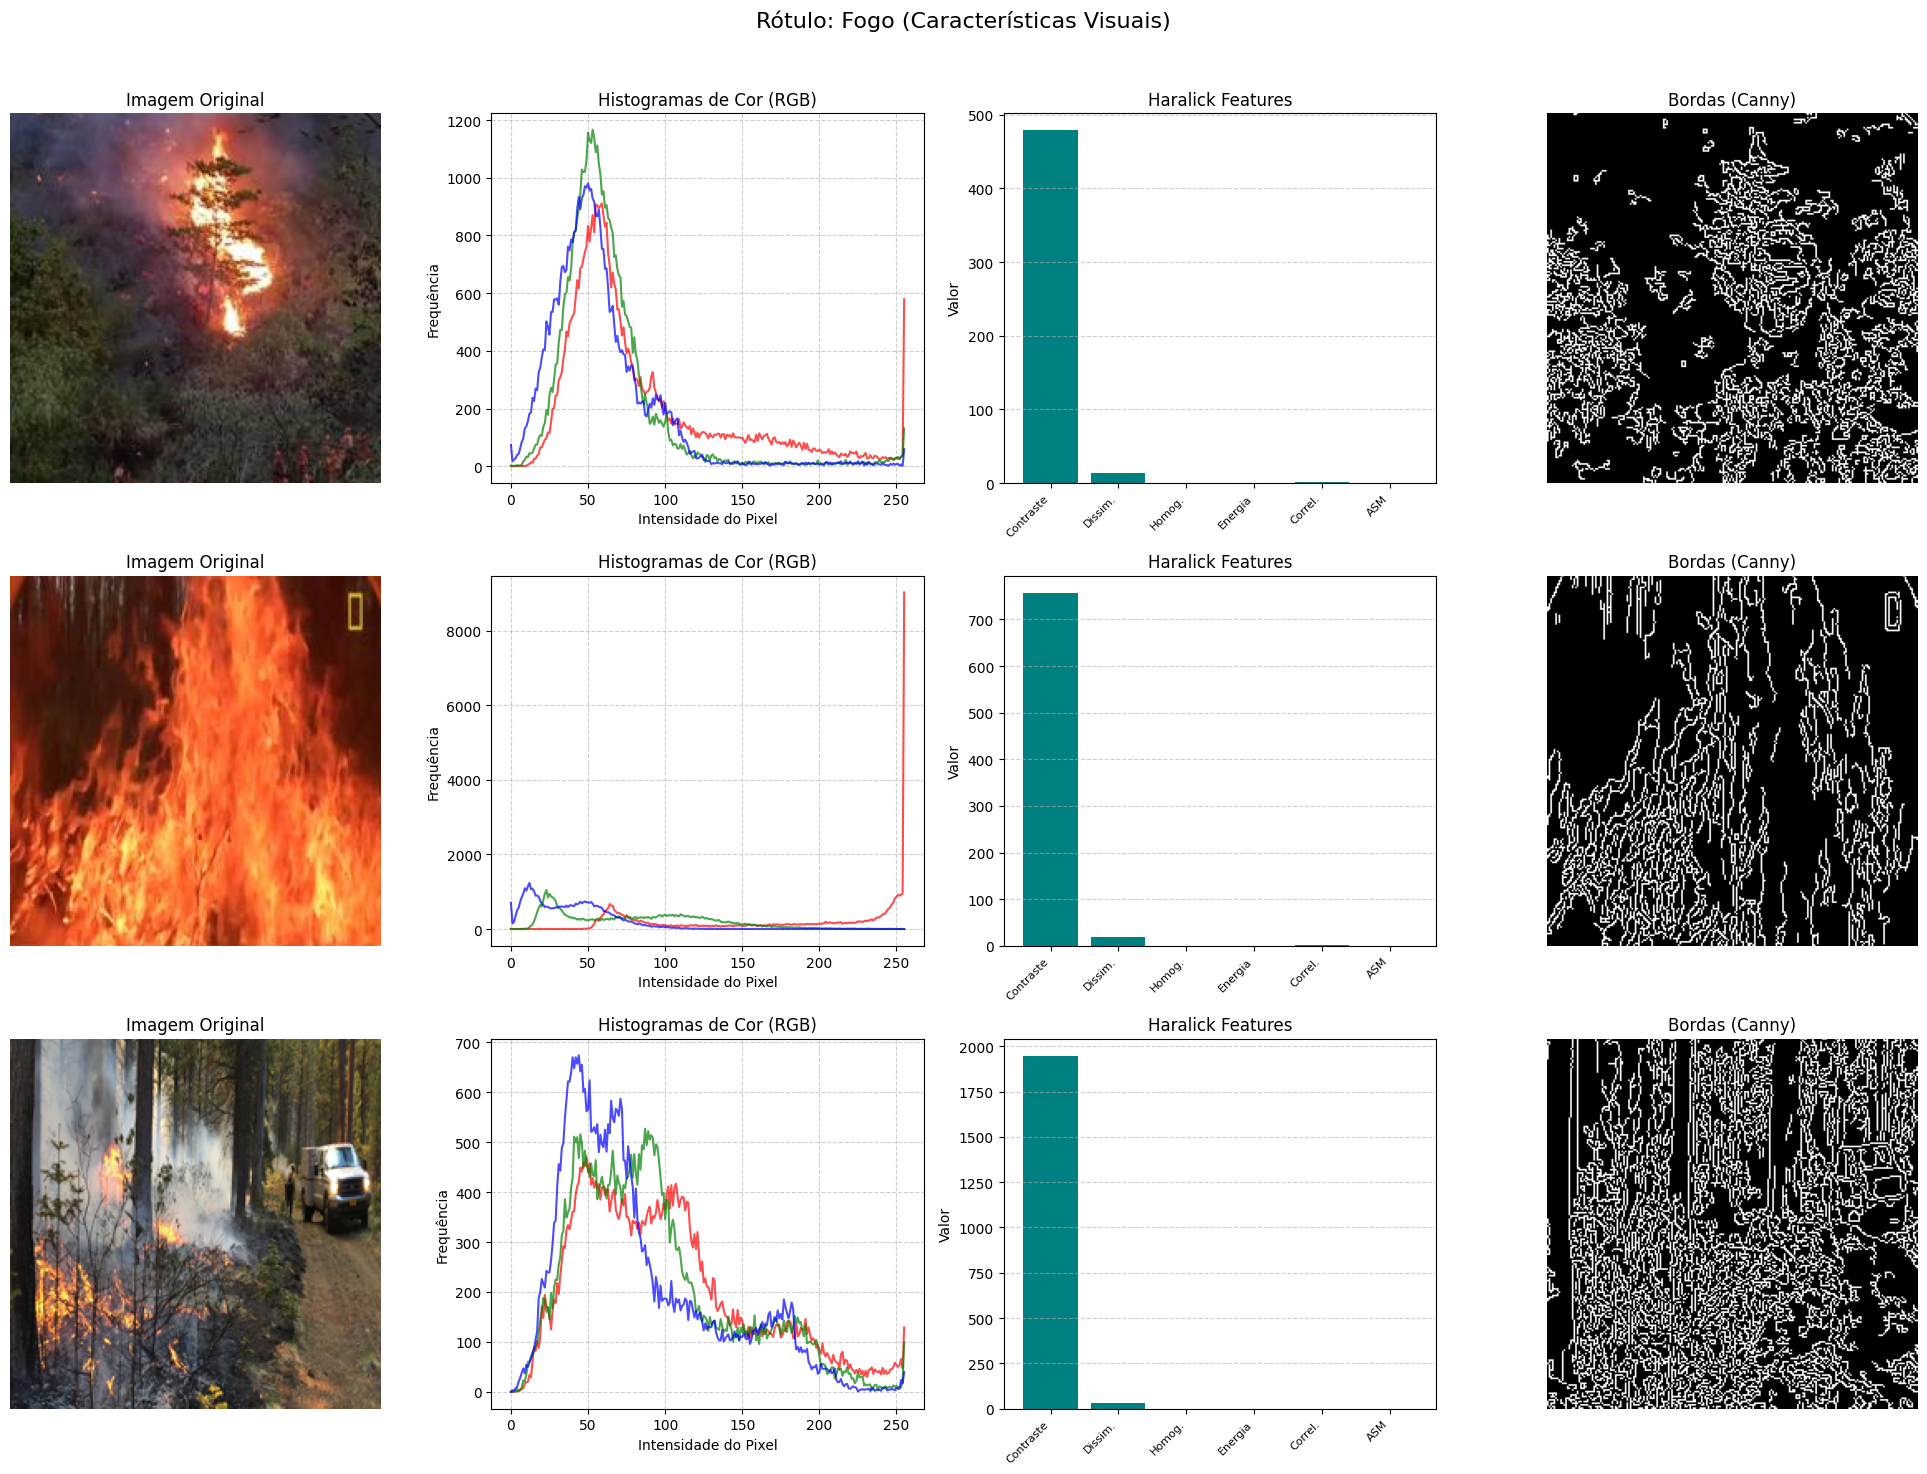

  Imagem 21573 - Rótulo 1:
    Momentos de Cor:
    Média (RGB): (0.44, 0.46, 0.51)
    StdDev (RGB): (0.13, 0.13, 0.17)
    Haralick: {'Contraste': '1282.732', 'Dissim.': '25.473', 'Homog.': '0.066', 'Energia': '0.013', 'Correl.': '0.428', 'ASM': '0.000'}
  Imagem 12196 - Rótulo 1:
    Momentos de Cor:
    Média (RGB): (0.47, 0.49, 0.50)
    StdDev (RGB): (0.25, 0.25, 0.25)
    Haralick: {'Contraste': '345.510', 'Dissim.': '12.326', 'Homog.': '0.160', 'Energia': '0.033', 'Correl.': '0.956', 'ASM': '0.001'}
  Imagem 11556 - Rótulo 1:
    Momentos de Cor:
    Média (RGB): (0.30, 0.39, 0.54)
    StdDev (RGB): (0.27, 0.21, 0.17)
    Haralick: {'Contraste': '1436.231', 'Dissim.': '21.685', 'Homog.': '0.254', 'Energia': '0.048', 'Correl.': '0.778', 'ASM': '0.002'}


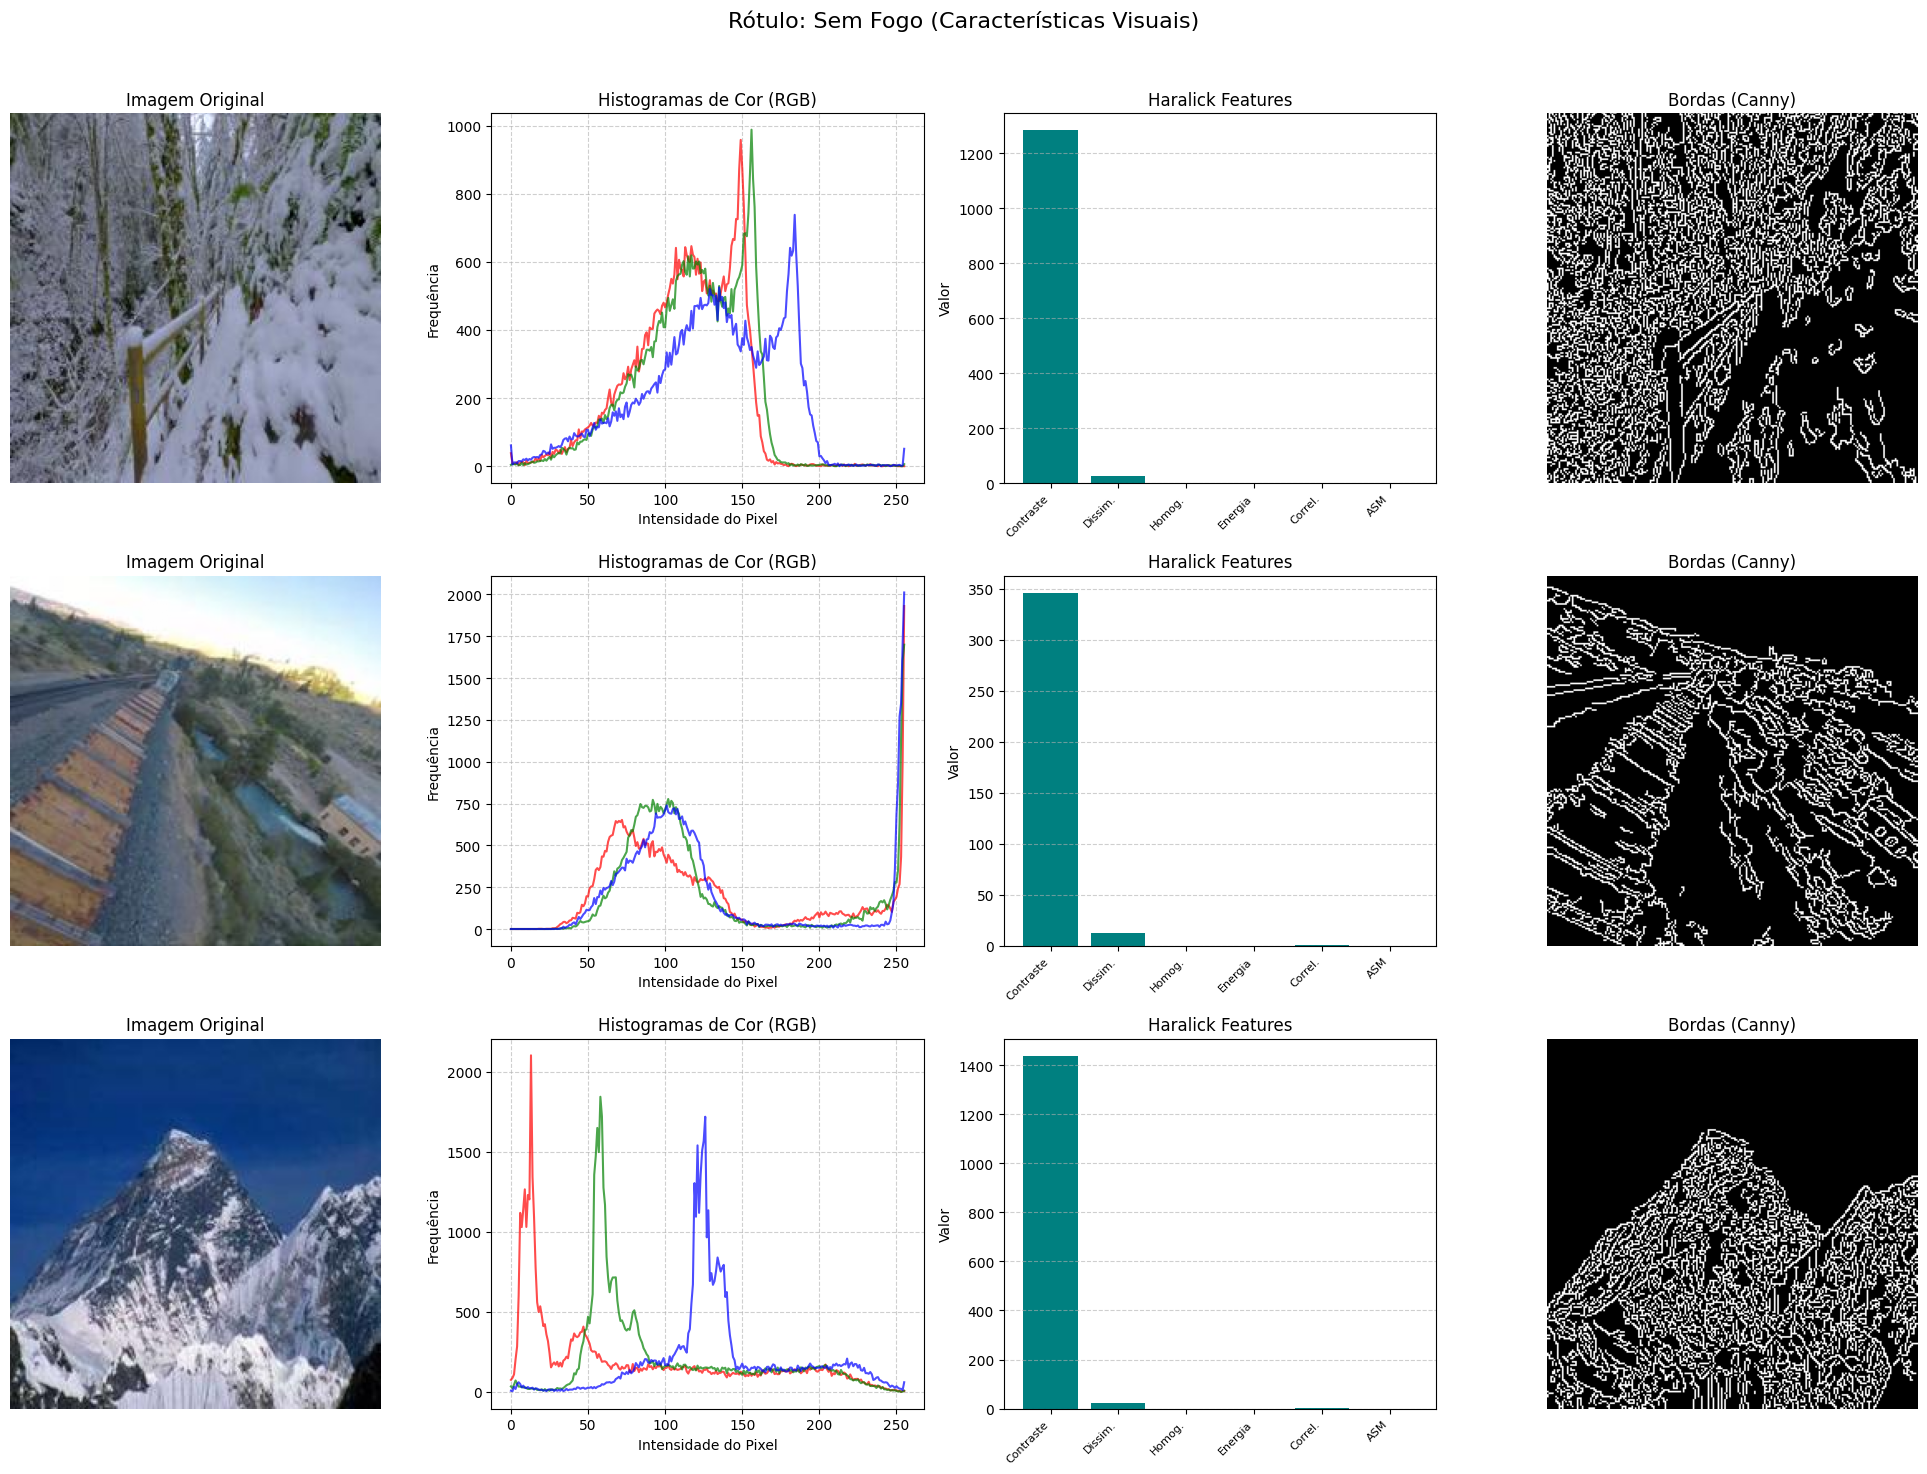

  Imagem 22071 - Rótulo 2:
    Momentos de Cor:
    Média (RGB): (0.40, 0.41, 0.42)
    StdDev (RGB): (0.25, 0.25, 0.27)
    Haralick: {'Contraste': '729.816', 'Dissim.': '14.287', 'Homog.': '0.128', 'Energia': '0.020', 'Correl.': '0.913', 'ASM': '0.000'}
  Imagem 28314 - Rótulo 2:
    Momentos de Cor:
    Média (RGB): (0.48, 0.47, 0.46)
    StdDev (RGB): (0.30, 0.32, 0.35)
    Haralick: {'Contraste': '724.646', 'Dissim.': '11.565', 'Homog.': '0.230', 'Energia': '0.054', 'Correl.': '0.945', 'ASM': '0.003'}
  Imagem 30639 - Rótulo 2:
    Momentos de Cor:
    Média (RGB): (0.42, 0.42, 0.42)
    StdDev (RGB): (0.17, 0.17, 0.17)
    Haralick: {'Contraste': '1156.054', 'Dissim.': '21.854', 'Homog.': '0.066', 'Energia': '0.011', 'Correl.': '0.688', 'ASM': '0.000'}


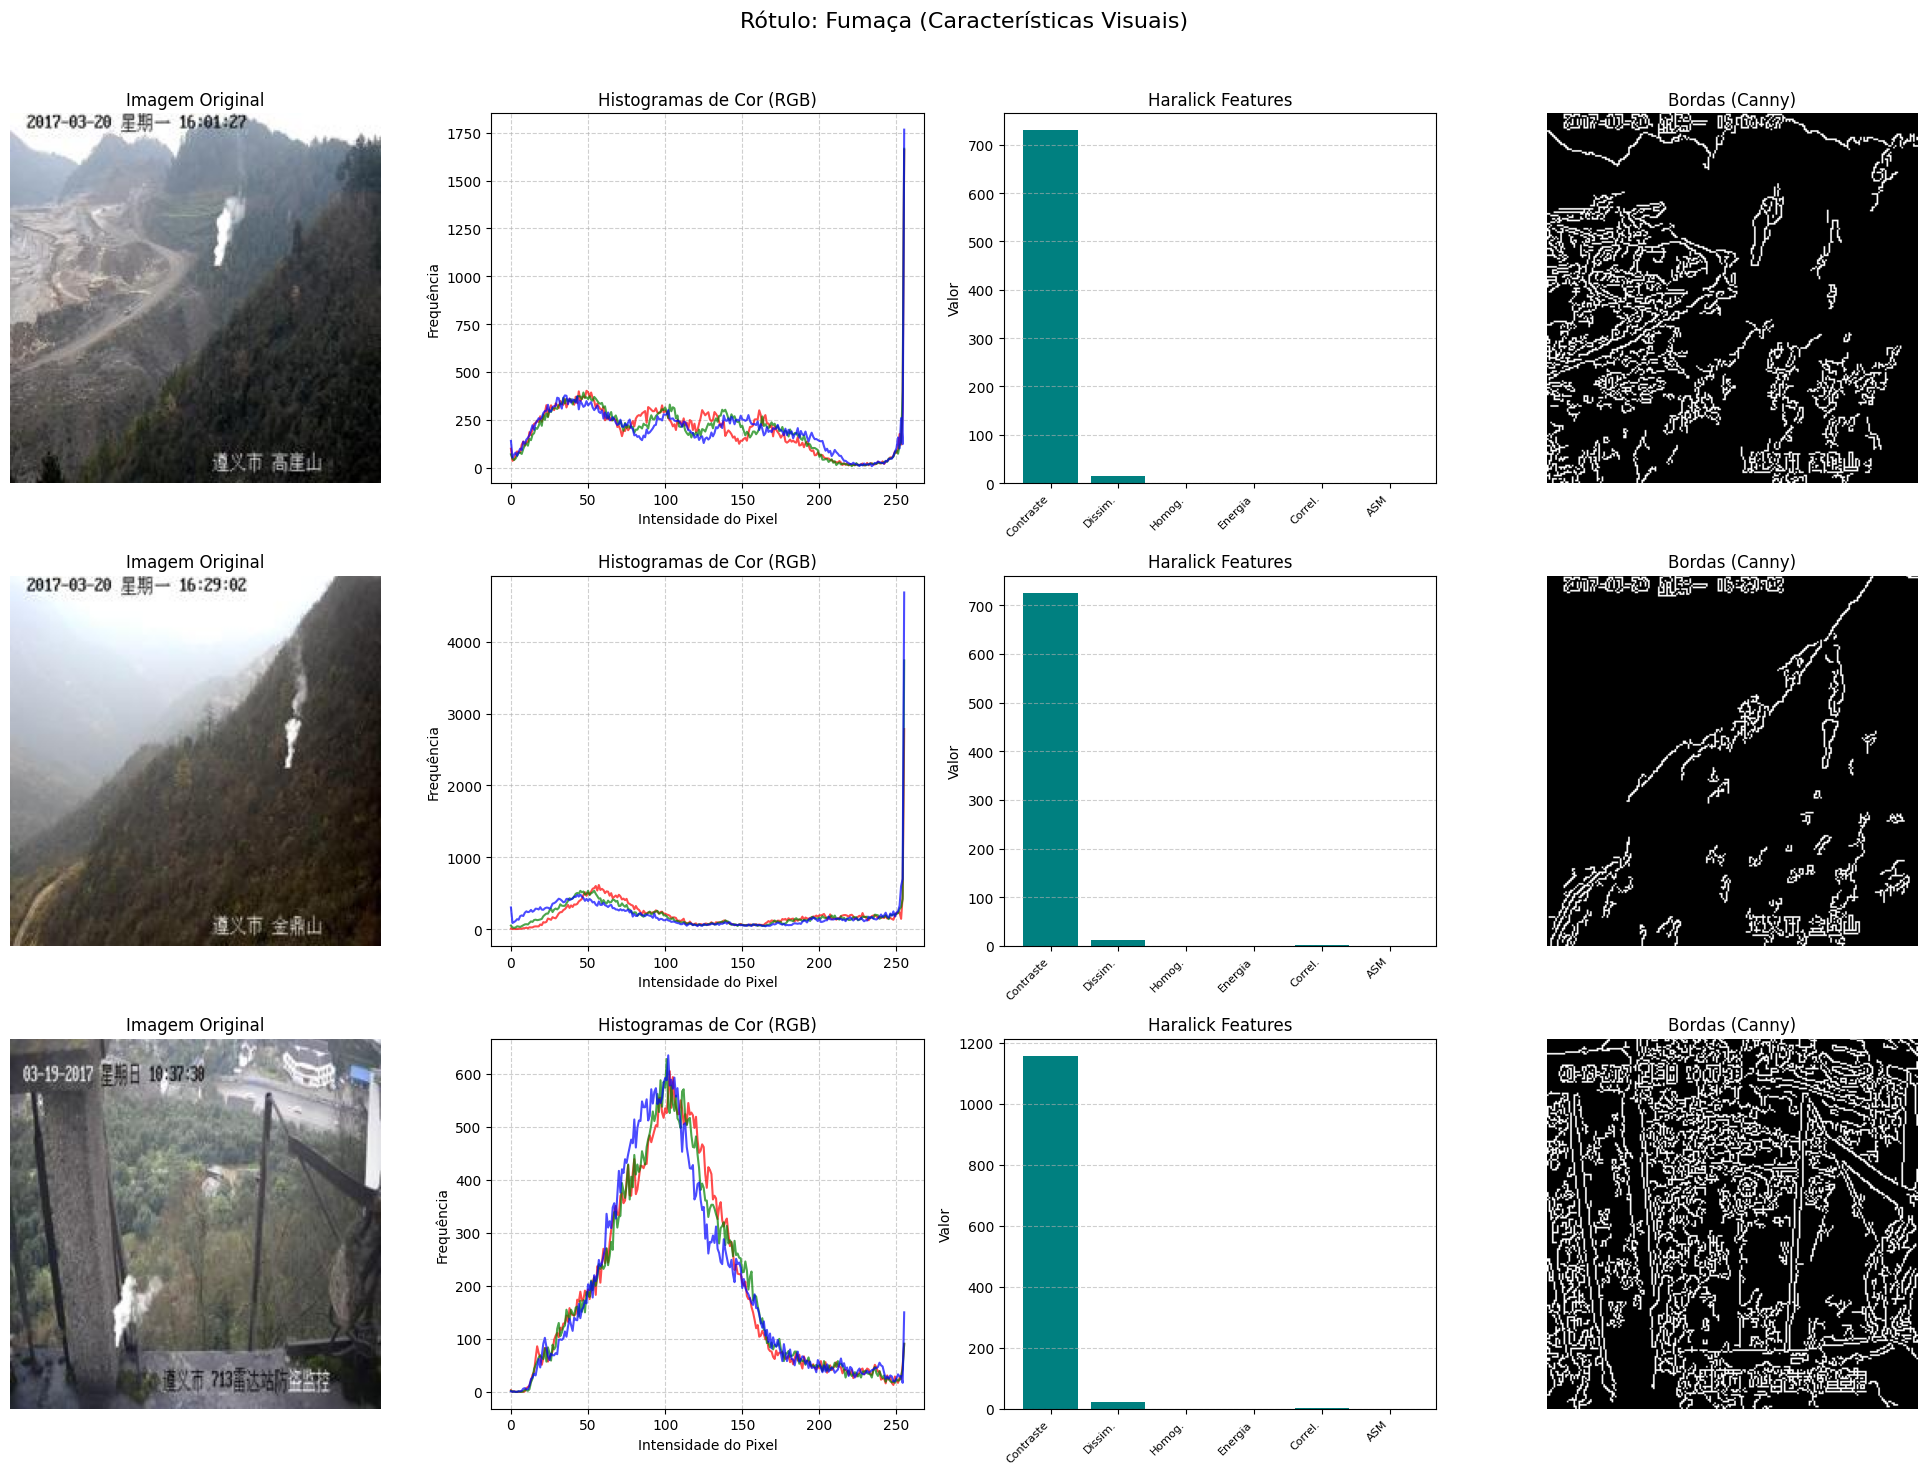

In [14]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

print("Processando Bloco Final: Extração de Características Visuais (Cor, Textura, Bordas)")

for rotulo in np.unique(rotulos_treino):
    indices_rotulo = np.where(rotulos_treino == rotulo)[0]
    if len(indices_rotulo) == 0:
        print(f"Nenhuma amostra encontrada para o rótulo: {rotulos_significado.get(rotulo, rotulo)}")
        continue

    num_a_selecionar = min(num_amostras_por_rotulo, len(indices_rotulo))
    if num_a_selecionar == 0:
        print(f"Nenhuma amostra a ser selecionada para o rótulo: {rotulos_significado.get(rotulo, rotulo)}")
        continue

    indices_amostra = np.random.choice(indices_rotulo, num_a_selecionar, replace=False)

    plt.figure(figsize=(20, 5 * num_a_selecionar))
    plt.suptitle(f'Rótulo: {rotulos_significado.get(rotulo, rotulo)} (Características Visuais)', fontsize=16)

    num_colunas = 4  # Agora temos 4 características: original, cor, Haralick, Canny

    for i, indice_imagem in enumerate(indices_amostra):
        imagem_normalizada = imagens_treino[indice_imagem]  # Assume float [0,1]
        imagem_uint8 = (imagem_normalizada * 255).astype(np.uint8)

        is_color = imagem_normalizada.ndim == 3 and imagem_normalizada.shape[-1] == 3

        if is_color:
            img_rgb_uint8 = imagem_uint8
            img_gray_uint8 = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2GRAY)
        else:
            img_gray_uint8 = np.squeeze(imagem_uint8)

        # 1. Imagem Original
        plt.subplot(num_a_selecionar, num_colunas, num_colunas * i + 1)
        if is_color:
            plt.imshow(imagem_normalizada)
        else:
            plt.imshow(imagem_normalizada, cmap='gray')
        plt.title('Imagem Original')
        plt.axis('off')

        # 2. Características de Cor: Histogramas e Momentos
        ax_color_hist = plt.subplot(num_a_selecionar, num_colunas, num_colunas * i + 2)
        moment_text_lines = ["Momentos de Cor:"]

        if is_color:
            colors = ('r', 'g', 'b')
            means = np.mean(imagem_normalizada, axis=(0, 1))
            stds = np.std(imagem_normalizada, axis=(0, 1))
            moment_text_lines.append(f"  Média (RGB): ({means[0]:.2f}, {means[1]:.2f}, {means[2]:.2f})")
            moment_text_lines.append(f"  StdDev (RGB): ({stds[0]:.2f}, {stds[1]:.2f}, {stds[2]:.2f})")

            for ch, color in enumerate(colors):
                hist = cv2.calcHist([img_rgb_uint8], [ch], None, [256], [0, 256])
                ax_color_hist.plot(hist, color=color, alpha=0.7)

            ax_color_hist.set_title('Histogramas de Cor (RGB)')
        else:
            mean_gray = np.mean(imagem_normalizada)
            std_gray = np.std(imagem_normalizada)
            moment_text_lines.append(f"  Média (Cinza): {mean_gray:.2f}")
            moment_text_lines.append(f"  StdDev (Cinza): {std_gray:.2f}")

            hist = cv2.calcHist([img_gray_uint8], [0], None, [256], [0, 256])
            ax_color_hist.plot(hist, color='black')
            ax_color_hist.set_title('Histograma Intensidade')

        print(f"  Imagem {indice_imagem} - Rótulo {rotulo}:")
        for line in moment_text_lines:
            print(f"    {line.strip()}")

        ax_color_hist.set_xlabel('Intensidade do Pixel')
        ax_color_hist.set_ylabel('Frequência')
        ax_color_hist.grid(True, linestyle='--', alpha=0.6)

        # 3. Textura: Haralick (GLCM)
        ax_haralick = plt.subplot(num_a_selecionar, num_colunas, num_colunas * i + 3)
        glcm = graycomatrix(img_gray_uint8, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)

        haralick_props_names = ['Contraste', 'Dissim.', 'Homog.', 'Energia', 'Correl.', 'ASM']
        try:
            haralick_features = [
                graycoprops(glcm, 'contrast')[0, 0],
                graycoprops(glcm, 'dissimilarity')[0, 0],
                graycoprops(glcm, 'homogeneity')[0, 0],
                graycoprops(glcm, 'energy')[0, 0],
                graycoprops(glcm, 'correlation')[0, 0],
                graycoprops(glcm, 'ASM')[0, 0],
            ]

            print(f"    Haralick: {dict(zip(haralick_props_names, ['{:.3f}'.format(f) for f in haralick_features]))}")
            ax_haralick.bar(haralick_props_names, haralick_features, color='teal')
            ax_haralick.set_title('Haralick Features')
            ax_haralick.set_ylabel('Valor')
            plt.setp(ax_haralick.get_xticklabels(), rotation=45, ha="right", fontsize=8)
        except Exception as e:
            print(f"    Erro ao calcular Haralick para imagem {indice_imagem}: {e}")
            ax_haralick.text(0.5, 0.5, "Erro Haralick", ha='center', va='center')

        ax_haralick.grid(True, linestyle='--', alpha=0.6, axis='y')

        # 4. Bordas: Detecção de Canny
        plt.subplot(num_a_selecionar, num_colunas, num_colunas * i + 4)
        bordas = cv2.Canny(img_gray_uint8, 50, 150)
        plt.imshow(bordas, cmap='gray')
        plt.title('Bordas (Canny)')
        plt.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



## Análise das Imagens da Classe **Fogo**

### Histogramas de Cor (RGB)  
As imagens apresentam picos notáveis no canal **vermelho (R)**, principalmente em intensidades altas (acima de 200), o que é consistente com a coloração característica das chamas.  
Em algumas imagens, o canal azul (B) e verde (G) aparecem com valores menores, formando um padrão de dominância do vermelho.  
Isso sugere que a informação de cor é altamente discriminativa para a detecção de fogo, sobretudo pela saturação e intensidade no canal vermelho.

### Haralick Features (GLCM)  
A principal característica que se destaca nas imagens de fogo é o **contraste**, com valores elevados em todas as amostras.  
Outras propriedades como **dissimilaridade** e **homogeneidade** têm valores significativamente menores, reforçando a ideia de que o fogo gera padrões texturais com **alta variação local de intensidade**.  
Esse comportamento é esperado, já que as chamas introduzem regiões muito claras (fogo intenso) intercaladas com sombras e fumaça.

### Bordas (Canny)  
As imagens apresentam **detecção intensa de contornos**, com muitos traços finos e delimitados.  
As bordas são frequentes em áreas com transições abruptas de intensidade luminosa, como ocorre no contorno das chamas e na interface entre o fogo e o fundo.  
Essa quantidade elevada de bordas diferencia o fogo de outras classes como "sem fogo", onde as bordas são mais suaves e menos densas.

---

## Análise das Imagens da Classe **Sem Fogo**

### Histogramas de Cor (RGB)  
As imagens sem fogo apresentam distribuições de cor mais equilibradas entre os canais vermelho, verde e azul.  
Os picos de intensidade costumam aparecer em faixas intermediárias (valores entre 80 e 200), com variações que refletem elementos do ambiente, como vegetação, neve, céu ou solo.  
Não há predominância clara de tons quentes, o que diferencia essa classe da classe "fogo", onde o vermelho tende a dominar.

### Haralick Features (GLCM)  
A principal característica observada é novamente o **contraste**, com valores elevados, especialmente em imagens com texturas marcantes como vegetação densa ou neve.  
Entretanto, o nível de contraste tende a ser mais estável e distribuído de forma mais uniforme do que nas imagens de fogo.  
As demais propriedades (dissimilaridade, homogeneidade, energia, etc.) permanecem em níveis baixos, sugerindo variação moderada nos padrões locais de textura.

### Bordas (Canny)  
As bordas são visíveis, porém seguem padrões mais estáticos e organizados.  
As imagens sem fogo tendem a produzir contornos associados a estruturas definidas como trilhos, encostas, montanhas ou troncos, com menos ruído visual.  
A densidade de bordas é menor e menos caótica do que nas imagens com fogo, o que pode ajudar a distinguir classes com base em complexidade de contorno.

---

## Análise das Imagens da Classe **Fumaça**

### Histogramas de Cor (RGB)  
As imagens com fumaça apresentam histogramas com distribuições de intensidade mais suaves e achatadas.  
Os canais RGB tendem a estar relativamente alinhados, com picos em valores intermediários e altos (acima de 200), especialmente quando a fumaça é clara e há forte iluminação.  
A ausência de dominância clara de um único canal diferencia essas imagens das de fogo (onde o vermelho se destaca) e das sem fogo (com distribuições mais definidas por objetos estáticos).

### Haralick Features (GLCM)  
A característica mais marcante nas imagens com fumaça continua sendo o **contraste**, embora em menor escala do que nas imagens de fogo.  
A fumaça cria regiões com variação de textura mais suave, o que se reflete em valores mais baixos de dissimilaridade e energia.  
Esse padrão está associado à natureza difusa da fumaça, que forma gradientes suaves e padrões de intensidade pouco definidos.

### Bordas (Canny)  
A detecção de bordas é menos intensa do que nas imagens com fogo, mas mais irregular que nas imagens sem fogo.  
As bordas aparecem em padrões quebrados, muitas vezes com pequenos fragmentos desconectados, representando as áreas flutuantes ou dispersas da fumaça.  
Esse comportamento pode ser um indicativo importante da presença de partículas leves e difusas, características da fumaça.

---

## Conclusão Geral sobre as Características Visuais

A análise conjunta das três classes — **fogo**, **fumaça** e **sem fogo** — revela padrões distintos nas características de cor, textura e bordas, os quais podem ser explorados para a diferenciação automática dessas categorias.

- **Imagens da classe Fogo** apresentam forte predominância do canal **vermelho**, com histogramas de cor concentrados em intensidades altas. A textura é altamente contrastante, refletida nos valores elevados de contraste nas features de Haralick. As bordas são densas e caóticas, com muitos contornos intensos, representando bem a natureza explosiva e irregular das chamas.

- **Imagens da classe Fumaça** exibem uma distribuição de cor mais homogênea, sem picos significativos em um único canal, especialmente quando a fumaça é clara e difusa. As texturas são mais suaves e os valores de contraste são medianos. A detecção de bordas mostra contornos fragmentados e irregulares, acompanhando o padrão flutuante e disperso da fumaça.

- **Imagens da classe Sem Fogo** têm histogramas mais equilibrados entre os canais RGB, sem saturação dominante. As texturas são mais organizadas e associadas a objetos estáticos, com contrastes definidos porém mais estáveis. As bordas detectadas são estruturadas e seguem linhas de objetos físicos como trilhos, vegetação ou edificações.

Essas diferenças indicam que os descritores utilizados — histogramas de cor, Haralick (GLCM) e detecção de bordas (Canny) — são capazes de capturar informações visuais relevantes para a separação entre as classes. A combinação desses elementos pode formar uma base sólida para aplicações de classificação supervisionada ou sistemas de alerta automático em cenários reais.


## Delimitação do Escopo e Justificativa Metodológica

As análises exploratórias conduzidas com imagens contendo fogo, fumaça e cenas sem fogo evidenciaram comportamentos visuais distintos entre essas classes. Enquanto o fogo se caracteriza por regiões altamente saturadas em vermelho, com forte contraste e contornos definidos, a fumaça tende a formar padrões difusos, com textura suave e bordas fragmentadas. Imagens sem fogo, por outro lado, exibem distribuição de cor mais equilibrada e estruturas visualmente estáveis. Essas observações motivaram a busca por modelos capazes de lidar com diferentes padrões visuais, especialmente em contextos naturais complexos.

Como ponto de partida, este trabalho se baseia no modelo fuzzy proposto por **Lopez-Alanis et al. (2025)**, que realiza segmentação de pixels com base em regras cromáticas contínuas. O modelo original combina subtrações de canais de diferentes espaços de cor (como `R - G`, `Y - Cr`, etc.) por meio de operadores fuzzy (mínimo, máximo, soma simétrica), organizados em estruturas otimizadas por um **algoritmo genético**. A saída é um mapa contínuo de pertinência à classe "fogo", posteriormente binarizado para avaliação com métricas como **F-measure** e **IoU**.

Entretanto, o artigo foca exclusivamente em informações de cor, o que limita sua capacidade de detectar **fumaça difusa, sombras ou objetos cromaticamente similares ao fogo**. Além disso, sua aplicação prática requer **máscaras de segmentação por pixel**, as quais **não estão disponíveis** no dataset utilizado neste projeto.

Diante disso, propomos uma **adaptação metodológica**. Em vez da segmentação por pixel, adotamos uma abordagem baseada na **extração de características globais por imagem**, representando cada imagem como um vetor de atributos visuais. Essa mudança permite aplicar modelos supervisionados convencionais para classificar imagens em três categorias: **fogo**, **fumaça** e **sem fogo**.

A nova proposta adiciona fontes complementares de informação visual:
- **Cor**: médias e desvios padrão dos canais RGB;
- **Textura**: estatísticas Haralick extraídas da matriz de coocorrência (GLCM), como contraste e homogeneidade;
- **Contornos**: densidade de bordas obtida com o operador de Canny.

Essa abordagem vetorizada reduz significativamente a complexidade computacional, mantém a interpretabilidade dos atributos e amplia o escopo do modelo original ao considerar padrões visuais não cromáticos. A avaliação será realizada com base nas métricas **F-measure** e **acurácia**, permitindo comparar objetivamente o desempenho dos modelos testados.

# Extração de Cor, Textura e Contorno

In [8]:
import numpy as np
import cv2
from skimage.feature import graycomatrix, graycoprops
import gc

# Função para extrair características globais de uma imagem RGB
def extrair_caracteristicas(imagem_rgb: np.ndarray) -> np.ndarray:
    features = []

    # Garantir tipo adequado
    imagem_rgb = imagem_rgb.astype(np.float32)

    # Média e desvio padrão por canal (R, G, B)
    medias = np.mean(imagem_rgb, axis=(0, 1))
    desvios = np.std(imagem_rgb, axis=(0, 1))
    features.extend(medias.tolist())
    features.extend(desvios.tolist())

    # Textura (Haralick)
    img_gray = cv2.cvtColor((imagem_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    glcm = graycomatrix(img_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    for p in props:
        val = graycoprops(glcm, p)[0, 0]
        features.append(val)

    # Bordas (Canny)
    bordas = cv2.Canny(img_gray, 100, 200)
    densidade_borda = np.sum(bordas > 0) / bordas.size
    features.append(densidade_borda)

    return np.array(features, dtype=np.float32)

# Extração de características do conjunto de treino
X_treino = np.array([extrair_caracteristicas(img) for img in imagens_treino])

# Atribuímos y_treino apenas como um alias para os rótulos já existentes.
# Isso evita duplicação em memória. O del abaixo remove apenas o nome rotulos_treino.
y_treino = rotulos_treino
# del imagens_treino
del rotulos_treino
gc.collect()

0

In [9]:
print("X_treino shape:", X_treino.shape)
print("y_treino shape:", y_treino.shape)

print("\nExemplo de vetor de características (amostra 0):")
print(X_treino[0])

unique, counts = np.unique(y_treino, return_counts=True)
print("\nDistribuição de rótulos:")
for rotulo, qtd in zip(unique, counts):
    print(f"Classe {rotulo}: {qtd} imagens")

X_treino shape: (31698, 13)
y_treino shape: (31698,)

Exemplo de vetor de características (amostra 0):
[5.3602314e-01 5.0130415e-01 4.9469626e-01 3.1114072e-01 2.5588718e-01
 2.3541427e-01 1.8308931e+02 5.6942463e+00 3.5256791e-01 5.3371854e-02
 9.7962767e-01 2.8485551e-03 6.2280770e-02]

Distribuição de rótulos:
Classe 0: 10794 imagens
Classe 1: 10796 imagens
Classe 2: 10108 imagens


In [10]:
# Extração de características do conjunto de teste
X_teste = np.array([extrair_caracteristicas(img) for img in imagens_teste])
y_teste = rotulos_teste  # Referência direta, sem duplicação

# Liberação de memória
del imagens_teste
del rotulos_teste
import gc
gc.collect()

# Feedback após a extração
print("X_teste shape:", X_teste.shape)
print("y_teste shape:", y_teste.shape)

print("\nExemplo de vetor de características (amostra 0):")
print(X_teste[0])

unique, counts = np.unique(y_teste, return_counts=True)
print("\nDistribuição de rótulos:")
for rotulo, qtd in zip(unique, counts):
    print(f"Classe {rotulo}: {qtd} imagens")


X_teste shape: (9443, 13)
y_teste shape: (9443,)

Exemplo de vetor de características (amostra 0):
[5.2438092e-01 4.9374720e-01 4.5226622e-01 2.0658939e-01 2.1292463e-01
 3.1516939e-01 2.0446335e+02 8.5531511e+00 2.5751397e-01 2.4769073e-02
 9.5277560e-01 6.1350694e-04 1.3883132e-01]

Distribuição de rótulos:
Classe 0: 3497 imagens
Classe 1: 3500 imagens
Classe 2: 2446 imagens


## Seleção Inicial de Modelos com Meta-Aprendizado

Nesta etapa, utilizamos uma abordagem automatizada de meta-aprendizado para comparar diversos modelos de classificação supervisionada. O objetivo é identificar rapidamente quais algoritmos apresentam melhor desempenho no problema de classificação de imagens em três categorias: fogo, fumaça e sem fogo.

Para isso, empregamos a biblioteca **LazyPredict**, que permite testar múltiplos modelos com configurações padrão e obter métricas comparativas como acurácia, tempo de treino e F1-score macro. Essa busca inicial pode ser entendida como uma **exploração do espaço de soluções em busca de um máximo local**, a partir do qual será possível aplicar técnicas de ajuste fino (tuning de hiperparâmetros) para refinar os modelos mais promissores.


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000729 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 25358, number of used features: 13
[LightGBM] [Info] Start training from score -1.077271
[LightGBM] [Info] Start training from score -1.077039
[LightGBM] [Info] Start training from score -1.142960


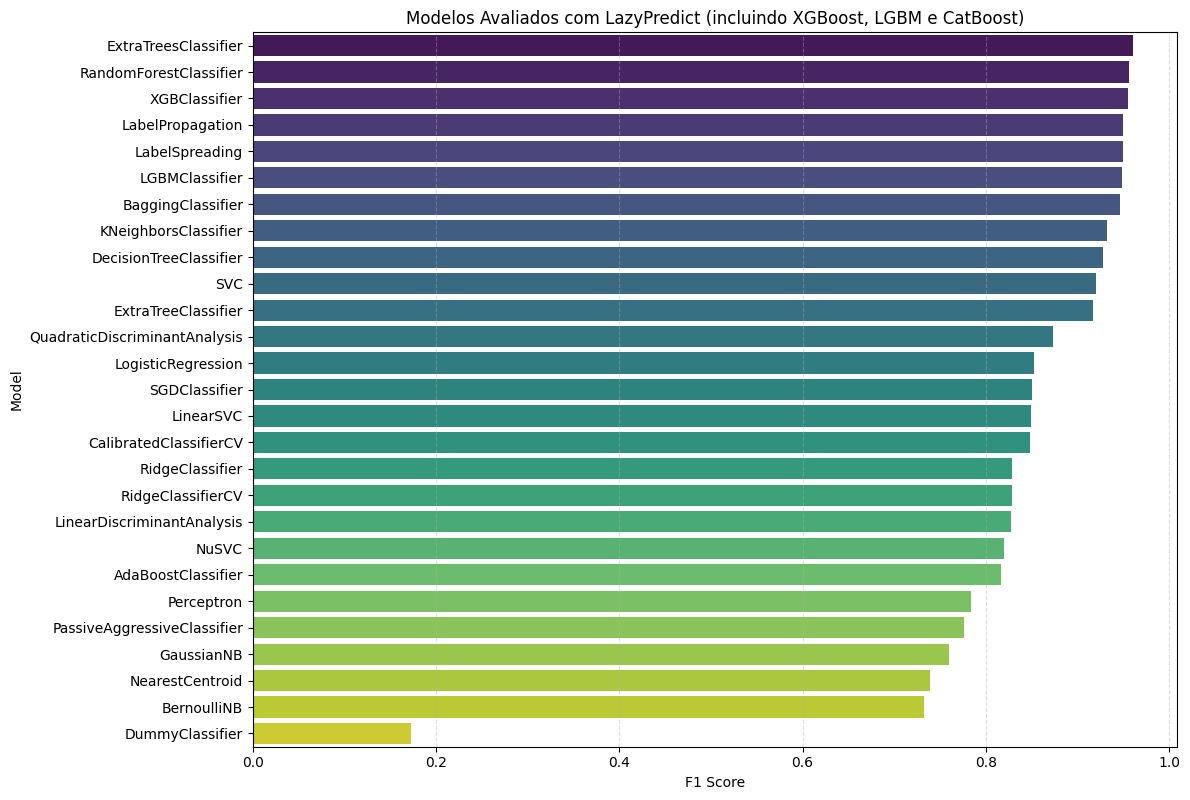

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
ExtraTreesClassifier,0.96,0.96,None,0.96,0.92
RandomForestClassifier,0.96,0.96,None,0.96,5.84
XGBClassifier,0.96,0.96,None,0.96,0.28
LabelPropagation,0.95,0.95,None,0.95,8.02
LabelSpreading,0.95,0.95,None,0.95,18.75
LGBMClassifier,0.95,0.95,None,0.95,0.25
BaggingClassifier,0.95,0.95,None,0.95,2.33
KNeighborsClassifier,0.93,0.93,None,0.93,0.29
DecisionTreeClassifier,0.93,0.93,None,0.93,0.38


In [12]:
from lazypredict.Supervised import LazyClassifier 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Força LazyPredict a não usar tqdm.notebook
os.environ["TQDM_NOTEBOOK"] = "false"

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_treino, y_treino, test_size=0.2, stratify=y_treino, random_state=42
)

# LazyPredict com todos os modelos possíveis (inclui XGBoost, LightGBM, CatBoost se instalados)
lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
modelos_treinados, _ = lazy_clf.fit(X_train, X_test, y_train, y_test)

# Ordenar por F1 Score
modelos_ordenados = modelos_treinados.sort_values(by="F1 Score", ascending=False)

# Mostrar gráfico com todos os modelos testados
plt.figure(figsize=(12, max(6, len(modelos_ordenados) * 0.3)))  # Altura adaptativa
sns.barplot(
    x=modelos_ordenados["F1 Score"],
    y=modelos_ordenados.index,
    palette="viridis"
)
plt.xlabel("F1 Score")
plt.title("Modelos Avaliados com LazyPredict (incluindo XGBoost, LGBM e CatBoost)")
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Mostrar a tabela completa no notebook
display(modelos_ordenados)


Escolheremos modelos dentre os que obtiveram F1 Score >= 95% para prosseguir com o refinamento de hiperparâmetros

In [21]:
# Filtrar modelos com F1 Score >= 0.95
limiar_f1 = 0.95
modelos_selecionados = modelos_ordenados[modelos_ordenados["F1 Score"] >= limiar_f1]

# Exibir os modelos selecionados
print(f"Modelos com F1 Score ≥ {limiar_f1}:\n")
print(modelos_selecionados[["F1 Score", "Accuracy"]])

# Lista dos nomes dos modelos
nomes_modelos_selecionados = modelos_selecionados.index.tolist()

Modelos com F1 Score ≥ 0.95:

                        F1 Score  Accuracy
Model                                     
ExtraTreesClassifier        0.96      0.96
RandomForestClassifier      0.96      0.96
XGBClassifier               0.96      0.96
LabelPropagation            0.95      0.95
LabelSpreading              0.95      0.95


## Seleção de Modelos para Ajuste de Hiperparâmetros

Com base nos resultados obtidos na etapa de meta-aprendizado com LazyPredict, foram selecionados três modelos com F1 Score superior a 0.95 para o refinamento de seus hiperparâmetros. A escolha considerou não apenas o desempenho inicial, mas também a diversidade nos perfis de aprendizado, de modo a explorar abordagens complementares.

Os modelos escolhidos são:

- **RandomForestClassifier**: Representa a família de modelos baseados em **bagging com árvores de decisão**. É amplamente utilizado por sua estabilidade, robustez e interpretabilidade, sendo adequado para dados tabulares com baixo pré-processamento.

- **XGBClassifier**: Um modelo de **Gradient Boosting**, conhecido por seu alto desempenho, controle refinado de regularização e capacidade de lidar com dados tabulares. Foi incluído por seu excelente equilíbrio entre bias e variância, além da ampla aceitação em competições e aplicações reais.

- **LabelSpreading**: Pertence à classe dos modelos **semi-supervisionados baseados em propagação de rótulos via grafos**. Foi incluído por apresentar uma lógica de aprendizado não convencional, capaz de capturar padrões de similaridade entre amostras que outros modelos supervisionados não exploram diretamente.

Essa diversidade visa não apenas encontrar o melhor desempenho individual, mas também compreender como diferentes paradigmas de aprendizado se comportam diante do problema de classificação de imagens florestais nas classes **fogo, fumaça e sem fogo**.


### Ajuste de Hiperparâmetros

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.semi_supervised import LabelSpreading
#from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
#import matplotlib.pyplot as plt
import time

# 1. RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, 
                       scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)
start = time.time()
grid_rf.fit(X_train, y_train)
print(f"\nRandomForest - Melhor F1: {grid_rf.best_score_:.4f}")
print("Melhores parâmetros:", grid_rf.best_params_)

# 2. XGBClassifier
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', tree_method='gpu_hist', random_state=42),
                        param_grid_xgb, scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print(f"\nXGBoost - Melhor F1: {grid_xgb.best_score_:.4f}")
print("Melhores parâmetros:", grid_xgb.best_params_)

# 3. LabelSpreading
param_grid_ls = {
    'kernel': ['rbf'],  # 'knn' também é válido, mas muito diferente em comportamento
    'gamma': [0.1, 0.5, 1, 5],
    'alpha': [0.1, 0.2, 0.3],
    'max_iter': [30, 50, 100]
}

grid_ls = GridSearchCV(LabelSpreading(), param_grid_ls, 
                       scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)
grid_ls.fit(X_train, y_train)
print(f"\nLabelSpreading - Melhor F1: {grid_ls.best_score_:.4f}")
print("Melhores parâmetros:", grid_ls.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits

RandomForest - Melhor F1: 0.9500
Melhores parâmetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Fitting 3 folds for each of 108 candidates, totalling 324 fits

XGBoost - Melhor F1: 0.9536
Melhores parâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.8}
Fitting 3 folds for each of 36 candidates, totalling 108 fits

LabelSpreading - Melhor F1: 0.7601
Melhores parâmetros: {'alpha': 0.1, 'gamma': 5, 'kernel': 'rbf', 'max_iter': 30}


### Predição dos modelos refinados sobre o conjunto de testes


===== Avaliação: RandomForest =====
              precision    recall  f1-score   support

        fogo       0.95      0.96      0.95      2159
    sem fogo       0.95      0.96      0.95      2159
      fumaça       0.98      0.96      0.97      2022

    accuracy                           0.96      6340
   macro avg       0.96      0.96      0.96      6340
weighted avg       0.96      0.96      0.96      6340



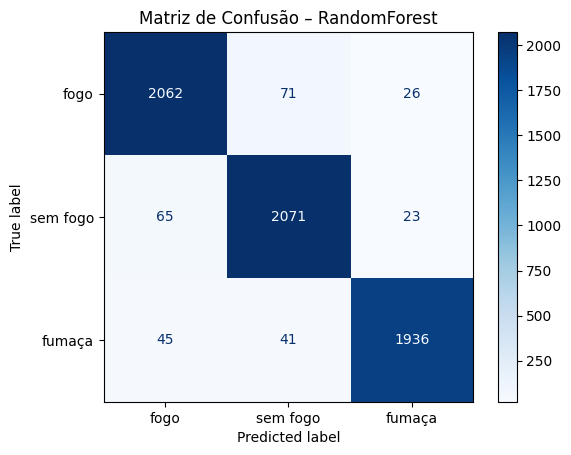


===== Avaliação: XGBoost =====
              precision    recall  f1-score   support

        fogo       0.95      0.97      0.96      2159
    sem fogo       0.96      0.95      0.96      2159
      fumaça       0.97      0.96      0.97      2022

    accuracy                           0.96      6340
   macro avg       0.96      0.96      0.96      6340
weighted avg       0.96      0.96      0.96      6340



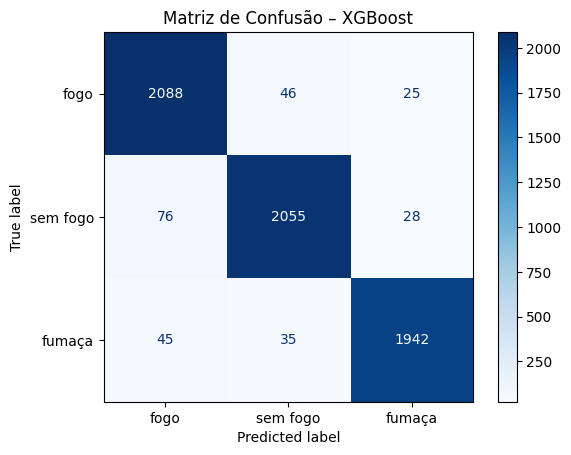


===== Avaliação: LabelSpreading =====
              precision    recall  f1-score   support

        fogo       0.71      0.78      0.74      2159
    sem fogo       0.74      0.64      0.69      2159
      fumaça       0.84      0.86      0.85      2022

    accuracy                           0.76      6340
   macro avg       0.76      0.76      0.76      6340
weighted avg       0.76      0.76      0.76      6340



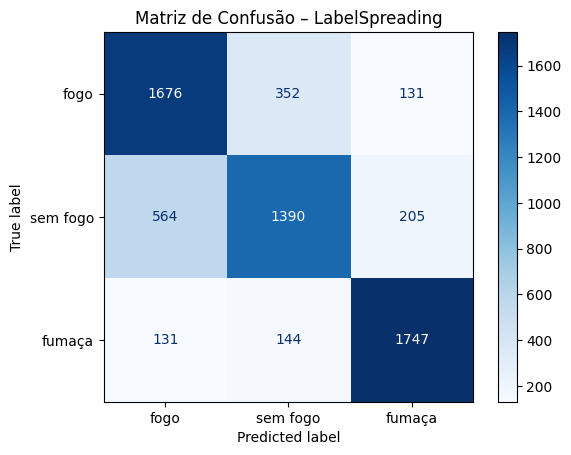

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dicionário com os modelos ajustados
modelos_finais = {
    'RandomForest': grid_rf.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_,
    'LabelSpreading': grid_ls.best_estimator_,
}

# Avaliação no conjunto de teste
for nome, modelo in modelos_finais.items():
    y_pred = modelo.predict(X_test)

    print(f"\n===== Avaliação: {nome} =====")
    print(classification_report(y_test, y_pred, target_names=["fogo", "sem fogo", "fumaça"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["fogo", "sem fogo", "fumaça"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusão – {nome}")
    plt.grid(False)
    plt.show()


### Resultado Final do Refinamento Modelos

Os três modelos selecionados foram avaliados no conjunto de teste utilizando métricas de classificação multiclasse. Os resultados mostram diferenças claras de desempenho entre eles:

- **XGBoost** apresentou o melhor desempenho geral, com F1-score macro de 0.96, superando ligeiramente o RandomForest em precisão e recall nas três classes.
- **RandomForest** também obteve excelente desempenho, com F1-score macro igualmente alto 0.96, mas levemente inferior nas métricas por classe.
- **LabelSpreading** teve desempenho significativamente inferior, com F1-score macro de 0.76, mostrando dificuldades especialmente na classe "sem fogo".

### Cálculo de IoU do XGBoost

In [27]:
from sklearn.metrics import jaccard_score

# y_pred = grid_xgb.best_estimator_.predict(X_test)

# Cálculo do IoU macro (Intersection over Union)
iou_macro = jaccard_score(y_test, y_pred, average='macro')

print(f"IoU (macro) do modelo XGBoost otimizado: {iou_macro:.4f}")


IoU (macro) do modelo XGBoost otimizado: 0.9230


### Comparação do modelo XGBoost com os resultados de Lopez-Alanis et al. (2025)

Utilizaremos a seguinte tabela, contendo o resultado dos autores originais, para comparação.

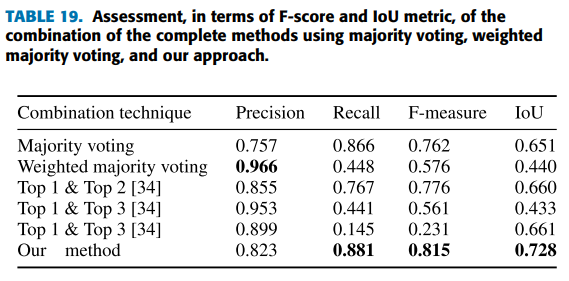

In [28]:
from IPython.display import Image, display

# Exibe diretamente a imagem
display(Image(filename='./img/tabela_resultados.png'))

## Comparação com o Trabalho de Lopez-Alanis et al. (2025)

| Técnica                       | Precision | Recall | F1-score | IoU   |
|------------------------------|-----------|--------|----------|-------|
| Majority voting              | 0.757     | 0.866  | 0.762    | 0.651 |
| Weighted majority voting     | 0.966     | 0.448  | 0.576    | 0.440 |
| Top 1 & Top 2 [34]           | 0.855     | 0.767  | 0.776    | 0.660 |
| Top 1 & Top 3 [34]           | 0.953     | 0.441  | 0.561    | 0.433 |
| **Our method (Lopez-Alanis)**| **0.823**     | **0.881**  | **0.815**   | **0.728** |
| **Este trabalho (XGBoost)**  | **0.960** | **0.960**  | **0.963** | **0.923** |

### Conclusão da Comparação com o Estado da Arte

A tabela acima apresenta uma comparação entre os resultados obtidos neste trabalho, utilizando o modelo XGBoost otimizado, e os métodos propostos por Lopez-Alanis et al. (2025). Observa-se que a abordagem desenvolvida neste projeto alcançou **valores superiores de F1-score (0.963)** e **IoU (0.923)** em relação aos reportados pelo método original (0.815 e 0.728, respectivamente), considerando os experimentos conduzidos no presente dataset.

Entretanto, vale destacar que os resultados do artigo original foram obtidos com o dataset **CORSICAN**, enquanto este trabalho utilizou um conjunto diferente de imagens, o que impede uma comparação direta e conclusiva de desempenho. Ainda assim, os resultados obtidos demonstram que a abordagem alternativa aqui proposta, baseada na extração de características visuais globais (cor, textura e contorno) e uso de modelos supervisionados é viável e eficaz para a detecção de fogo e fumaça em ambientes naturais.

Essa estratégia se mostra especialmente promissora diante da ausência de máscaras de segmentação por pixel no dataset utilizado, oferecendo uma solução prática, interpretável e de alto desempenho para o problema, mesmo sob restrições reais de anotação.